[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reza0mowlavi/huggingface-llm-basics/blob/main/notebooks/4.Batching%20with%20vLLM.ipynb)


Run the first cell in Colab. It will clone the repo if needed, copy the shared files into a local working folder, and switch into that folder. After that first cell runs, the notebook can import `utils.py` and read `gsm8k/` from `/content/workshop-notebooks`.

In [ ]:
import os
from pathlib import Path
import shutil

repo_dir = Path('/content/huggingface-llm-basics')
work_dir = Path('/content/workshop-notebooks')
work_dir.mkdir(parents=True, exist_ok=True)

if not repo_dir.exists():
    !git clone https://github.com/reza0mowlavi/huggingface-llm-basics.git /content/huggingface-llm-basics

shutil.copy2(repo_dir / 'notebooks' / 'utils.py', work_dir / 'utils.py')
if (work_dir / 'gsm8k').exists():
    shutil.rmtree(work_dir / 'gsm8k')
shutil.copytree(repo_dir / 'notebooks' / 'gsm8k', work_dir / 'gsm8k')
%cd /content/workshop-notebooks


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"

# LLM Inference Workshop – Part 4
## Batched Inference with vLLM (PagedAttention Runtime)

In Notebook 3, we used HuggingFace `.generate()` with **naive batching**:
- left padding
- sorting by length to reduce padding waste

In this notebook, we solve the same task using **vLLM**:
- no manual padding
- variable-length prompts handled efficiently (paged KV + runtime scheduling)
- same dataset (GSM8K), same prompt format, same accuracy computation

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown

from datasets import load_dataset, Dataset
from transformers import AutoTokenizer  # only for chat template formatting

from vllm import LLM, SamplingParams, RequestOutput

from utils import MATH_PROMPT, extract_last_after_hashes, compute_accuracy

np.random.seed(0)

## Why vLLM Helps

HuggingFace static batching requires padding within each batch to make tensor shapes uniform.

vLLM uses:
- **paged KV cache** (block-based KV storage)
- **runtime-level scheduling**
- can handle variable sequence lengths without your manual padding logic

Important implication for this notebook:
✅ We feed a list of prompts (strings) of different lengths directly.  
❌ No `tokenizer.pad`, no left padding, no attention masks needed.

In [3]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

MAX_NEW_TOKENS = 2048


# Decoding policy (keep deterministic for accuracy)
TEMPERATURE = 0.0  # irrelevant if DO_SAMPLE=False

## Tokenizer for Chat Template Formatting

Even though vLLM has its own tokenizer internally, we reuse HuggingFace tokenizer
here because we want the same `apply_chat_template()` behavior as Notebook 2.

We will pass the final formatted prompt string to vLLM.


In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded.")

Tokenizer loaded.


## Load GSM8K

We will:
1) Load GSM8K (test split)
2) Convert each example into:
   - `prompt` (chat-formatted string)
   - `y_true` (ground-truth final answer)

In [6]:
# Load GSM8K
dataset = load_dataset("gsm8k", split="test")

# Reduce size for workshop speed
# dataset = dataset.select(range(512))

def format_prompt(example: dict) -> dict:
    messages = [
        {"role": "system", "content": "You are a math expert."},
        {"role": "user", "content": MATH_PROMPT.format(question=example["question"])},
    ]

    formatted = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    return {
        "prompt": formatted,
        "y_true": extract_last_after_hashes(example["answer"]).strip().lower(),
    }

dataset = dataset.map(format_prompt, batched=False)
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1319 [00:00<?, ? examples/s]

Dataset({
    features: ['question', 'answer', 'prompt', 'y_true'],
    num_rows: 1319
})

## Initialize vLLM

`vllm.LLM` loads the model and starts the runtime that manages:
- KV blocks (paged KV cache)
- scheduling / batching internally

Notes:
- If you run out of GPU memory, reduce `MAX_NEW_TOKENS`, reduce dataset size, or use a smaller model.
- We keep decoding deterministic (`DO_SAMPLE=False`) to make accuracy stable.

In [7]:
# Create vLLM runtime
llm = LLM(
    model=MODEL_NAME,
    # Name or local path of the model to load.
    # vLLM will download (if needed), load weights, and initialize its runtime.

    max_model_len=2048+MAX_NEW_TOKENS,
    # Maximum total sequence length (prompt + generated tokens)
    # that the runtime will allow.
    #
    # This determines:
    #   - Maximum KV cache allocation per request
    #   - Upper bound on logical context window
    #
    # Important:
    #   If set too high → more KV memory reserved → fewer concurrent requests.
    #   If set too low → long prompts may be rejected.

    enforce_eager=True,
    # Forces eager execution instead of CUDA graph capture.
    # Slightly less performant than full graph execution, but more flexible.

    enable_prefix_caching=True,
    # Enables prefix caching.
    # If multiple prompts share the same prefix (e.g., system prompt),
    # vLLM can reuse the computed KV cache for that prefix,
    # reducing prefill computation and improving throughput.
    
    gpu_memory_utilization=0.9,
    # Fraction of total GPU memory that vLLM is allowed to use
    # for model weights + KV cache blocks.
    # Higher values allow larger batches / longer sequences,
    # but increase risk of OOM if set too aggressively.


    # tensor_parallel_size=1,
    # Number of GPUs used for tensor parallelism.
    # >1 splits model weights across GPUs.
    # Keep at 1 for a simple single-GPU workshop setup.
)

sampling_params = SamplingParams(
    max_tokens=MAX_NEW_TOKENS,
    #
    temperature=TEMPERATURE,
    # temperature=0 → greedy decoding.
)

print("vLLM initialized.")

INFO 04-05 11:36:44 [utils.py:253] non-default args: {'seed': None, 'max_model_len': 4096, 'enable_prefix_caching': True, 'disable_log_stats': True, 'enforce_eager': True, 'model': 'Qwen/Qwen2.5-0.5B-Instruct'}
WARNING 04-05 11:36:44 [arg_utils.py:1175] `seed=None` is equivalent to `seed=0` in V1 Engine. You will no longer be allowed to pass `None` in v0.13.
INFO 04-05 11:36:45 [model.py:637] Resolved architecture: Qwen2ForCausalLM
INFO 04-05 11:36:45 [model.py:1750] Using max model len 4096
INFO 04-05 11:36:45 [scheduler.py:228] Chunked prefill is enabled with max_num_batched_tokens=8192.
WARNING 04-05 11:36:45 [vllm.py:601] Enforce eager set, overriding optimization level to -O0
INFO 04-05 11:36:45 [vllm.py:707] Cudagraph is disabled under eager mode
(EngineCore_DP0 pid=2195585) INFO 04-05 11:36:46 [core.py:93] Initializing a V1 LLM engine (v0.12.0) with config: model='Qwen/Qwen2.5-0.5B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-0.5B-Instruct', skip_tokenizer_init=Fa

(EngineCore_DP0 pid=2195585) /nfs/home/seymol/conda_envs/v3.13/lib/python3.13/site-packages/tvm_ffi/_optional_torch_c_dlpack.py:181: UserWarning: Failed to JIT torch c dlpack extension, EnvTensorAllocator will not be enabled.
(EngineCore_DP0 pid=2195585) We recommend installing via `pip install torch-c-dlpack-ext`
(EngineCore_DP0 pid=2195585)   warnings.warn(


(EngineCore_DP0 pid=2195585) INFO 04-05 11:36:50 [cuda.py:411] Using FLASH_ATTN attention backend out of potential backends: ['FLASH_ATTN', 'FLASHINFER', 'TRITON_ATTN', 'FLEX_ATTENTION']
(EngineCore_DP0 pid=2195585) INFO 04-05 11:36:51 [weight_utils.py:527] No model.safetensors.index.json found in remote.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


(EngineCore_DP0 pid=2195585) INFO 04-05 11:36:51 [default_loader.py:308] Loading weights took 0.27 seconds
(EngineCore_DP0 pid=2195585) INFO 04-05 11:36:52 [gpu_model_runner.py:3549] Model loading took 0.9277 GiB memory and 1.440000 seconds
(EngineCore_DP0 pid=2195585) INFO 04-05 11:36:53 [gpu_worker.py:359] Available KV cache memory: 33.18 GiB
(EngineCore_DP0 pid=2195585) INFO 04-05 11:36:53 [kv_cache_utils.py:1286] GPU KV cache size: 2,899,248 tokens
(EngineCore_DP0 pid=2195585) INFO 04-05 11:36:53 [kv_cache_utils.py:1291] Maximum concurrency for 4,096 tokens per request: 707.82x
(EngineCore_DP0 pid=2195585) INFO 04-05 11:36:53 [core.py:254] init engine (profile, create kv cache, warmup model) took 1.66 seconds
(EngineCore_DP0 pid=2195585) WARNING 04-05 11:36:55 [vllm.py:608] Inductor compilation was disabled by user settings,Optimizations settings that are only active duringInductor compilation will be ignored.
(EngineCore_DP0 pid=2195585) INFO 04-05 11:36:55 [vllm.py:707] Cudagraph

## Batch with vLLM

In [8]:
prompts = list(dataset["prompt"])

In [9]:
start = time.perf_counter()
outputs: list[RequestOutput] = llm.generate(prompts, sampling_params)
end = time.perf_counter()

Adding requests:   0%|          | 0/1319 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1319 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

In [10]:
elapsed = end - start
print(f"Elapsed time: {elapsed:.4f} seconds\n")

Elapsed time: 41.3285 seconds



In [11]:
print(outputs[0].outputs[0].finished())
print(outputs[0].outputs[0].finish_reason)

True
stop


In [12]:
print(outputs[0].outputs[0].token_ids)

[1249, 8253, 1246, 1753, 53665, 3643, 518, 279, 20336, 6, 3081, 1449, 1899, 11, 582, 1184, 311, 1795, 1493, 7354, 1447, 16, 13, 3070, 47866, 279, 2790, 1372, 315, 18805, 17113, 553, 279, 77778, 304, 264, 1899, 25, 1019, 256, 481, 53665, 594, 77778, 10962, 220, 16, 21, 18805, 817, 1899, 382, 17, 13, 3070, 35, 24308, 279, 1372, 315, 18805, 53665, 49677, 304, 264, 1899, 25, 1019, 256, 481, 53665, 49677, 220, 18, 18805, 369, 17496, 1449, 6556, 624, 256, 481, 2932, 49677, 220, 19, 18805, 369, 27815, 54304, 1330, 1449, 1899, 624, 256, 481, 15277, 11, 279, 2790, 1372, 315, 18805, 1340, 49677, 304, 264, 1899, 374, 510, 257, 1124, 9640, 257, 220, 18, 1124, 1318, 90, 320, 8960, 9349, 9139, 488, 220, 19, 1124, 1318, 90, 320, 65, 1765, 9139, 284, 220, 22, 1124, 1318, 90, 18805, 532, 257, 1124, 2533, 18, 13, 3070, 47866, 279, 1372, 315, 18805, 53665, 30778, 304, 264, 1899, 25, 1019, 256, 481, 2932, 30778, 279, 26313, 315, 279, 18805, 518, 279, 20336, 6, 3081, 624, 256, 481, 576, 2790, 1372, 315, 18

In [13]:
print(len(outputs[0].outputs[0].token_ids))

353


In [14]:
print(outputs[0].outputs[0].text)

To determine how much Janet makes at the farmers' market every day, we need to follow these steps:

1. **Calculate the total number of eggs laid by the ducks in a day:**
   - Janet's ducks lay 16 eggs per day.

2. **Determine the number of eggs Janet eats in a day:**
   - Janet eats 3 eggs for breakfast every morning.
   - She eats 4 eggs for baking muffins every day.
   - Therefore, the total number of eggs she eats in a day is:
     \[
     3 \text{ (breakfast)} + 4 \text{ (baking)} = 7 \text{ eggs}
     \]

3. **Calculate the number of eggs Janet sells in a day:**
   - She sells the remainder of the eggs at the farmers' market.
   - The total number of eggs laid is 16.
   - Subtract the number of eggs she eats from the total:
     \[
     16 \text{ (total)} - 7 \text{ (eaten)} = 9 \text{ eggs}
     \]

4. **Determine the price per egg at the farmers' market:**
   - The price per egg is $2.

5. **Calculate the total amount of money Janet makes at the farmers' market every day:**
   -

## Extracting generated text and stats.

In [ ]:
responses = [x.outputs[0].text for x in outputs]

generated_token_counts = [len(x.outputs[0].token_ids) for x in outputs]

finished_flags = [x.outputs[0].finished() for x in outputs]

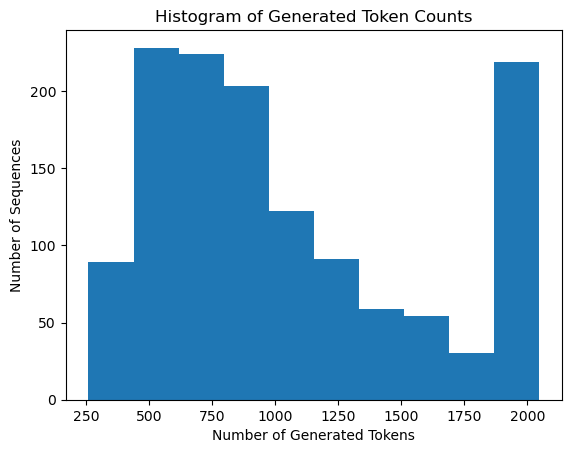

Statistics:
Min tokens: 258
Max tokens: 2048
Mean tokens: 1062.83


In [ ]:
plt.figure()
plt.hist(generated_token_counts)

plt.title("Histogram of Generated Token Counts")
plt.xlabel("Number of Generated Tokens")
plt.ylabel("Number of Sequences")

plt.show()

print("Statistics:")
print(f"Min tokens: {min(generated_token_counts)}")
print(f"Max tokens: {max(generated_token_counts)}")
print(f"Mean tokens: {sum(generated_token_counts)/len(generated_token_counts):.2f}")

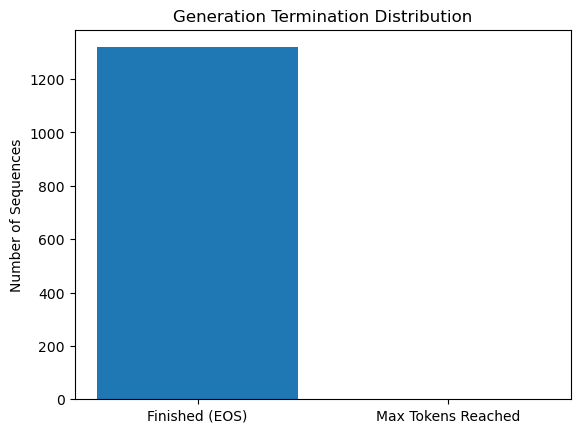

Finished (EOS): 1319
Max Tokens Reached: 0


In [ ]:
num_finished = sum(finished_flags)
num_not_finished = len(finished_flags) - num_finished

categories = ["Finished (EOS)", "Max Tokens Reached"]
counts = [num_finished, num_not_finished]

plt.figure()
plt.bar(categories, counts)
plt.title("Generation Termination Distribution")
plt.ylabel("Number of Sequences")
plt.show()

print(f"Finished (EOS): {num_finished}")
print(f"Max Tokens Reached: {num_not_finished}")

## Compute the accuracy of the model

In [ ]:
results = compute_accuracy(
    responses=responses,
    dataset=dataset
)

print(f"Accuracy: {results['accuracy']:.4f}")
print(f"Correct: {results['correct']} / {results['total']}")

Accuracy: 0.8423
Correct: 1111 / 1319
